# CIFAR-10 Image Classification Challenge

**Multi-class image classification**

Your challenge is to develop a machine learning model for classifying images in the classic [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

This is a great opportunity to learn about some core concepts and ideas in **deep learning** and **computer vision** using the popular machine learning library, [PyTorch](https://pytorch.org/). In particular, this challenge will give you the chance to learn about training and using convolutional neural networks (CNNs), which are ubiquitous in deep learning.

This Jupyter notebook will guide you through some of the various general stages involved in machine learning projects, including data visualisation, data preprocessing, model training and model evaluation, and afterwards, you will be able to submit your test set predictions for evaluation on the [DOXA AI](https://doxaai.com/competition/cifar-10) platform.

**Before you get started, make sure to [sign up for an account](https://doxaai.com/sign-up) if you do not already have one and [enrol to take part](https://doxaai.com/competition/cifar-10) in the challenge.**

**If you have any questions, feel free to ask them in the [DOXA Community Discord server](https://discord.gg/MUvbQ3UYcf).**


## Background

The [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) is a classic image dataset in machine learning collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. Its training set consists of 50,000 32&times;32 colour images, where each image belongs to one of ten classes: `airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship` and `truck`.

![CIFAR-10](https://pytorch.org/tutorials/_images/cifar10.png)


## Installing and importing useful packages

To get started, we will install and import a few packages we will need. To install PyTorch (including `torchvision`) if you do not already have it, check out the PyTorch [installation instructions](https://pytorch.org/get-started/locally/).


In [1]:
%pip install numpy matplotlib torchinfo timm
%pip install -U doxa-cli

Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 8.8 MB/s eta 0:00:00
  Created wheel for halo: filename=halo-0.0.31-py3-none-any.whl size=11232 sha256=4e52442798462a3061bd3ca3e34f0dde680c84303d7cb5966acf03dd63eb795a
  Stored in directory: /root/.cache/pip/wheels/0b/b2/f8/376708b4c66e68a1a7d40aaba26521645e7f5ad3b9ef756031
Successfully built halo
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: charset-normalizer
    Found existing installation: charset-normalizer 3.4.4
    Uninstalling charset-normalizer-3.4.4:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Loading & exploring the data

First, we'll download the data if we don't already have it.


In [3]:
import os

if not os.path.exists("data"):
    os.makedirs("data")

    !curl -L https://github.com/DoxaAI/educational-challenges/releases/download/cifar-10/cifar-10-data.npz --output data/data.npz

data = np.load("data/data.npz")

data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  161M  100  161M    0     0   150M      0  0:00:01  0:00:01 --:--:--  430M


NpzFile 'data/data.npz' with keys: training_data, training_targets, test_data

The `data.npz` file is a compressed NumPy zip archive containing the training dataset features (i.e. the images), the training dataset targets (the ten class labels encoded ordinally) and the test dataset features.

Each image in our 50,000-image training dataset has the shape `(3, 32, 32)`, which corresponds to the number of channels (red, green and blue), the height and the width of each image. Each value is encoded as an 8-bit unsigned integer, where values range from `0` to `255`.

Let's quickly verify this by checking the shapes of these three NumPy arrays and inspecting the raw pixel values of the first image in the training dataset:


In [4]:
print("Training features shape:", data["training_data"].shape)
print("Training targets shape: ", data["training_targets"].shape)
print("Test features shape:    ", data["test_data"].shape)

data["training_data"][0]

Training features shape: (50000, 3, 32, 32)
Training targets shape:  (50000,)
Test features shape:     (10000, 3, 32, 32)


array([[[ 95,  98, 106, ...,  99, 104, 101],
        [101, 109, 119, ...,  92,  98, 104],
        [ 97, 104, 118, ...,  97,  99, 106],
        ...,
        [193, 198, 198, ..., 171, 158, 164],
        [198, 208, 207, ..., 179, 168, 165],
        [216, 212, 208, ..., 182, 185, 189]],

       [[ 74,  79,  88, ...,  70,  74,  71],
        [ 79,  89,  99, ...,  65,  72,  78],
        [ 81,  89, 104, ...,  73,  75,  83],
        ...,
        [186, 191, 191, ..., 165, 152, 158],
        [189, 200, 200, ..., 173, 162, 159],
        [208, 205, 200, ..., 177, 179, 183]],

       [[ 59,  58,  62, ...,  49,  54,  51],
        [ 64,  68,  74, ...,  46,  52,  58],
        [ 62,  65,  75, ...,  55,  57,  64],
        ...,
        [181, 184, 181, ..., 168, 155, 162],
        [191, 196, 192, ..., 174, 164, 161],
        [205, 201, 195, ..., 176, 179, 182]]], dtype=uint8)

Now, let's visualise the data by looking at a subset of the images in the training dataset:


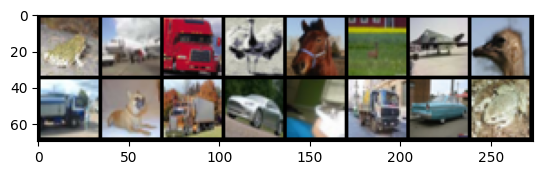

In [5]:
grid = torchvision.utils.make_grid(torch.from_numpy(data["training_data"][:16]))

# imshow() expects images to be (height, width, channels) rather than (channels, height, width)
plt.imshow(grid.permute(1, 2, 0))

In [6]:
CLASSES = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

[CLASSES[c] for c in data["training_targets"][:16]]

['frog',
 'plane',
 'truck',
 'bird',
 'horse',
 'deer',
 'plane',
 'bird',
 'truck',
 'dog',
 'truck',
 'car',
 'cat',
 'truck',
 'car',
 'frog']

## Preparing the data

First, let's split the training data we have been given into a training set and a separate validation set on which we can test the models we train.


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    data["training_data"], data["training_targets"], test_size=0.2
)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((40000, 3, 32, 32), (40000,), (10000, 3, 32, 32), (10000,))

Now, let's create a PyTorch [`VisionDataset`](https://pytorch.org/vision/main/generated/torchvision.datasets.VisionDataset.html) implementation so that we can work with the data more easily.


In [8]:
from typing import Any, Callable


class CIFAR10(torchvision.datasets.VisionDataset):
    def __init__(
        self,
        transform: Callable[..., Any],
        features: np.ndarray,
        targets: np.ndarray = None,
    ) -> None:
        super().__init__(transform=transform)

        self.features = torch.from_numpy(features)
        self.targets = torch.from_numpy(targets) if targets is not None else None

    def __getitem__(self, index: int) -> Any:
        if self.targets is not None:
            return self.transform(self.features[index]), self.targets[index]

        return self.transform(self.features[index])

    def __len__(self) -> int:
        return self.features.shape[0]

In [9]:
from torchvision.transforms import v2

# ImageNet standard normalization values for pre-trained models
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

training_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [10]:
training_dataset = CIFAR10(
    features=X_train,
    targets=y_train,
    transform=training_transform,
)

validation_dataset = CIFAR10(
    features=X_valid,
    targets=y_valid,
    transform=test_transform,
)

## Defining a model

In [11]:
import torch
import torch.nn as nn
import timm

class Model(nn.Module):
    def __init__(self, model_name='resnetv2_50x1_bit', num_classes=10):
        super().__init__()
        
        self.model = timm.create_model(model_name, pretrained=True)

        self.model.stem.conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.stem.pool = nn.Identity() # Loại bỏ MaxPool để tránh làm mờ ảnh nhỏ

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.stem.conv.parameters():
            param.requires_grad = True

        for param in self.model.stages[3].parameters():
            param.requires_grad = True

        # 4. Sửa Head (Dựa trên kiến trúc Conv2d bạn vừa gửi)
        # Lấy số channel đầu vào (2048 trong kiến trúc của bạn)
        in_channels = self.model.head.fc.in_channels 
        
        # Thay thế head cũ bằng Sequential mới để phù hợp với Linear classifier
        self.model.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(in_channels, num_classes)
        )
        
        for param in self.model.head.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

model = Model(num_classes=10).to(device)
model

/usr/local/lib/python3.12/dist-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model(
  (model): ResNetV2(
    (stem): Sequential(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (pad): ConstantPad2d(padding=(1, 1, 1, 1), value=0.0)
      (pool): Identity()
    )
    (stages): Sequential(
      (0): ResNetStage(
        (blocks): Sequential(
          (0): PreActBottleneck(
            (downsample): DownsampleConv(
              (conv): StdConv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (norm): Identity()
            )
            (norm1): GroupNormAct(
              32, 64, eps=1e-05, affine=True
              (drop): Identity()
              (act): ReLU(inplace=True)
            )
            (conv1): StdConv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): GroupNormAct(
              32, 64, eps=1e-05, affine=True
              (drop): Identity()
              (act): ReLU(inplace=True)
            )
            (conv2): StdConv2d(64, 64, kernel_size=(3, 3

The [`torchinfo`](https://github.com/TylerYep/torchinfo) package provides a useful `summary()` function that can provide some additional information about our model, such as input and output tensor shapes, as well as the number of trainable parameters. If your model has a huge number of trainable parameters (often from a large `Linear` layer), it will require more memory (and may potentially be harder to train in certain circumstances).


In [12]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 32, 32), 
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
Model (Model)                                                [1, 3, 32, 32]       [1, 10]              --                   Partial
├─ResNetV2 (model)                                           [1, 3, 32, 32]       [1, 10]              --                   Partial
│    └─Sequential (stem)                                     [1, 3, 32, 32]       [1, 64, 34, 34]      --                   True
│    │    └─Conv2d (conv)                                    [1, 3, 32, 32]       [1, 64, 32, 32]      1,728                True
│    │    └─ConstantPad2d (pad)                              [1, 64, 32, 32]      [1, 64, 34, 34]      --                   --
│    │    └─Identity (pool)                                  [1, 64, 34, 34]      [1, 64, 34, 34]      --                   --
│    └─Sequential (stages)                                   [1, 64, 34, 34]      [1, 2048

# Training the model


In [13]:
BATCH_SIZE = 256

training_dataloader = torch.utils.data.DataLoader(
    training_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True
)

validation_dataloader = torch.utils.data.DataLoader(
    validation_dataset, batch_size=BATCH_SIZE
)

In [14]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimiser = optim.AdamW(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=0.01
)

EPOCHS = 50
scheduler = CosineAnnealingLR(optimiser, T_max=EPOCHS, eta_min=1e-6)

In [15]:
training_losses = []
validation_losses = []

In [16]:
import numpy as np

def mixup_data(x, y, alpha=0.4, device='cuda'):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [17]:
for epoch in range(EPOCHS):
    model.train()
    count = 0
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(training_dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device) # Chuyển lên GPU sớm
        
        inputs_mixed, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha=0.4, device=device)
        
        optimiser.zero_grad()

        outputs = model(inputs_mixed)

        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        
        loss.backward()
        optimiser.step()
        scheduler.step()

        size = inputs.size(0)
        running_loss += loss.item() * size
        count += size

        if i % 100 == 99:
            print(f"Training epoch: {epoch + 1:2d},  batch: {i + 1:5d},  loss: {running_loss / count:.3f}")

    training_losses.append(running_loss / count)

    model.eval()
    count = 0
    running_loss = 0.0

    with torch.inference_mode():
        for i, (inputs, labels) in enumerate(validation_dataloader, 0):
            # Make predictions for the batch
            test_predictions = model(inputs.to(device))

            # Compute the loss
            loss = criterion(test_predictions, labels.to(device))

            # Update our statistics
            size = test_predictions.size(0)
            running_loss += loss.item() * size
            count += size

        validation_losses.append(running_loss / count)
        print(f"Validation epoch: {epoch + 1:2d},  loss: {running_loss / count:.3f}")

    # Save checkpoint after each epoch
    torch.save(model.state_dict(), f'cifar10_resnet50_epoch_{epoch+1}.pth')
    print(f"Checkpoint saved for epoch {epoch+1}")

Training epoch:  1,  batch:   100,  loss: 1.912
Validation epoch:  1,  loss: 1.069
Checkpoint saved for epoch 1
Training epoch:  2,  batch:   100,  loss: 1.407
Validation epoch:  2,  loss: 0.800
Checkpoint saved for epoch 2
Training epoch:  3,  batch:   100,  loss: 1.212
Validation epoch:  3,  loss: 0.612
Checkpoint saved for epoch 3
Training epoch:  4,  batch:   100,  loss: 1.149
Validation epoch:  4,  loss: 0.716
Checkpoint saved for epoch 4
Training epoch:  5,  batch:   100,  loss: 1.077
Validation epoch:  5,  loss: 0.563
Checkpoint saved for epoch 5
Training epoch:  6,  batch:   100,  loss: 1.081
Validation epoch:  6,  loss: 0.455
Checkpoint saved for epoch 6
Training epoch:  7,  batch:   100,  loss: 0.913
Validation epoch:  7,  loss: 0.477
Checkpoint saved for epoch 7
Training epoch:  8,  batch:   100,  loss: 1.005
Validation epoch:  8,  loss: 0.402
Checkpoint saved for epoch 8
Training epoch:  9,  batch:   100,  loss: 0.969
Validation epoch:  9,  loss: 0.444
Checkpoint saved for 

Great &ndash; our model has finished training! 🥳

We can now take a look at our training and validation loss curves:


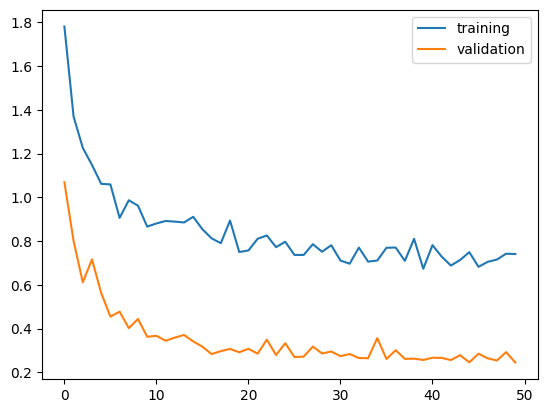

In [18]:
plt.plot(training_losses, label="training")
plt.plot(validation_losses, label="validation")
plt.legend()

In addition to looking at the cross-entropy loss, we can also compute a final set of statistics (such as the model's accuracy) and a confusion matrix for the validation dataset:


In [19]:
validation_predictions = []

model.eval()
with torch.inference_mode():
    for i, (inputs, labels) in enumerate(validation_dataloader, 0):
        # Select the class with the highest value for each instance in the dataset
        _, predicted_classes = model(inputs.to(device)).max(1)

        validation_predictions.extend(predicted_classes.cpu().numpy())

              precision    recall  f1-score   support

       plane      0.939     0.972     0.955       980
         car      0.963     0.972     0.967      1041
        bird      0.955     0.913     0.934       969
         cat      0.876     0.855     0.865      1039
        deer      0.957     0.920     0.938       968
         dog      0.843     0.896     0.869       998
        frog      0.962     0.963     0.963      1032
       horse      0.952     0.953     0.953       959
        ship      0.975     0.965     0.970      1037
       truck      0.948     0.953     0.950       977

    accuracy                          0.936     10000
   macro avg      0.937     0.936     0.936     10000
weighted avg      0.937     0.936     0.936     10000



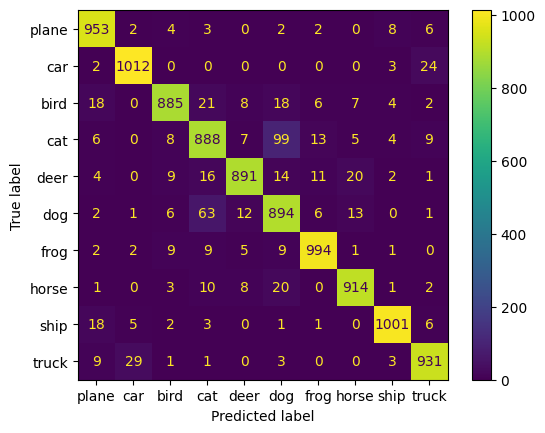

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(
    classification_report(
        y_true=y_valid, y_pred=validation_predictions, digits=3, target_names=CLASSES
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_true=y_valid, y_pred=validation_predictions, display_labels=CLASSES
)

From this, we can gain a greater insight into the performance of our model, which may give us ideas as to how we could improve.


## Submitting our predictions to the DOXA AI platform

We are now ready to generate predictions for the test set and upload our work to the DOXA AI platform for evaluation! 👀

**Make sure to [enrol to take part](https://doxaai.com/competition/cifar-10) in the challenge if you have not already done so.**


In [21]:
test_dataset = CIFAR10(features=data["test_data"], transform=test_transform)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [22]:
test_predictions = []

model.eval()
with torch.inference_mode():
    for i, inputs in enumerate(test_dataloader, 0):
        # Select the class with the highest value for each instance in the test dataset
        _, predicted_classes = model(inputs.to(device)).max(1)

        test_predictions.extend(predicted_classes.cpu().numpy())

print(*test_predictions)

3 9 5 4 9 0 3 8 7 4 7 5 7 1 4 0 6 2 8 0 0 1 9 4 9 0 9 6 5 3 4 5 6 6 2 2 8 1 8 5 6 7 2 9 3 4 1 5 3 6 7 5 5 3 8 3 8 3 4 1 7 8 8 5 3 8 7 5 3 1 7 6 7 7 8 9 2 4 5 5 2 0 6 9 6 0 4 5 2 3 0 0 0 3 2 7 3 6 0 9 7 7 7 9 3 4 1 0 2 7 8 9 5 7 2 3 7 2 2 1 5 4 6 2 0 2 2 5 2 2 6 6 9 3 9 0 9 8 3 0 8 6 3 4 7 2 5 4 1 9 6 1 0 4 4 6 0 3 7 4 5 0 8 9 2 3 3 4 9 8 3 4 5 0 1 4 3 6 0 3 4 2 5 1 0 1 4 5 0 4 0 3 9 3 5 3 3 2 6 1 2 7 6 9 2 8 2 7 5 9 9 6 4 9 2 7 8 8 2 2 3 4 4 7 5 0 7 1 1 6 3 1 9 2 0 2 1 7 5 7 5 0 2 5 0 8 3 6 9 3 3 6 4 7 5 2 9 1 3 2 6 5 9 6 6 0 7 2 2 9 3 2 5 9 5 8 1 6 4 1 1 9 6 1 1 1 3 4 8 3 3 2 8 9 1 7 4 4 6 4 0 5 0 2 5 2 9 3 3 5 6 4 2 9 8 1 4 9 7 5 9 2 6 3 5 7 6 5 2 8 6 9 6 1 4 0 9 6 6 2 9 8 8 3 1 9 7 7 3 7 6 7 7 3 2 7 6 0 3 7 9 7 0 3 0 1 7 8 4 6 8 5 2 0 1 1 3 6 5 4 9 0 0 6 0 8 1 9 5 2 0 2 0 5 3 3 1 1 3 5 6 9 1 6 9 0 0 7 6 8 5 7 1 1 1 1 3 0 6 1 2 6 5 1 8 9 7 5 8 2 7 1 9 8 9 0 8 4 5 7 8 1 4 5 5 5 8 8 3 3 4 5 0 8 8 5 9 1 4 2 4 0 8 6 2 0 6 0 9 5 7 0 1 8 3 5 3 2 0 8 5 7 6 2 0 6 4 9 2 1 0 8 5 4 0 3 9 2 3 1 

In [23]:
import torch

# Save the state dictionary of the final trained model
# You can choose to save the model from a specific epoch, e.g., 'cifar10_resnet50_epoch_50.pth'
final_model_path = 'cifar10_resnet50_final.pth'
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to cifar10_resnet50_final.pth


In [24]:
# Prepare our submission
os.makedirs("submission", exist_ok=True)

with open("submission/doxa.yaml", "w") as f:
    f.write(
        "competition: cifar-10\nenvironment: cpu\nlanguage: python\nentrypoint: run.py\n"
    )

with open("submission/run.py", "w") as f:
    contents = "\\n".join([str(prediction) for prediction in test_predictions])
    f.write(
        f"""import os
with open(os.environ["DOXA_STREAMS"] + "/out", "w") as f:
    f.write("{contents}")"""
    )

Next, we need to make sure we are logged in:


In [25]:
# !doxa login

Finally, we can submit the predictions for evaluation:


In [26]:
# !doxa upload submission

**Reasoning**:
The subtask requires extracting specific metrics from the classification report. First, I will generate the full classification report as a string. Then, I will parse this string to find the lines corresponding to the specified problematic classes and extract their precision, recall, and F1-score.



In [27]:
from sklearn.metrics import classification_report

problematic_classes = ['cat', 'dog', 'car', 'truck', 'ship', 'plane']

# Generate the full classification report as a string
report_str = classification_report(
    y_true=y_valid, y_pred=validation_predictions, digits=3, target_names=CLASSES,
    output_dict=False # Get string output for easier parsing
)

print("Classification Report for Problematic Classes:")
print("------------------------------------------------")

# Split the report into lines and process
report_lines = report_str.split('\n')

# Find the header line to determine column positions
header_line = report_lines[1] # Assumes header is typically the second line

# Create a dictionary to store results for problematic classes
problematic_metrics = {}

for line in report_lines:
    # Strip whitespace and check if the line starts with any of our problematic classes
    stripped_line = line.strip()
    for cls_name in problematic_classes:
        if stripped_line.startswith(cls_name):
            # Extract numbers after the class name
            parts = stripped_line.split()
            try:
                class_index_end = 0
                for i, part in enumerate(parts):
                    if not part.isalpha(): # First non-alpha part usually signals start of numbers
                        class_index_end = i
                        break

                precision = float(parts[1])
                recall = float(parts[2])
                f1_score = float(parts[3])

                problematic_metrics[cls_name] = {
                    'precision': precision,
                    'recall': recall,
                    'f1_score': f1_score
                }
            except (IndexError, ValueError) as e:
                print(f"Could not parse line for class {cls_name}: {line}. Error: {e}")
            break # Found the class, move to the next line

for cls_name in problematic_classes:
    if cls_name in problematic_metrics:
        metrics = problematic_metrics[cls_name]
        print(f"Class: {cls_name:<10} | Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f} | F1-Score: {metrics['f1_score']:.3f}")
    else:
        print(f"Metrics for class {cls_name} not found in report.")

Classification Report for Problematic Classes:
------------------------------------------------
Class: cat        | Precision: 0.876 | Recall: 0.855 | F1-Score: 0.865
Class: dog        | Precision: 0.843 | Recall: 0.896 | F1-Score: 0.869
Class: car        | Precision: 0.963 | Recall: 0.972 | F1-Score: 0.967
Class: truck      | Precision: 0.948 | Recall: 0.953 | F1-Score: 0.950
Class: ship       | Precision: 0.975 | Recall: 0.965 | F1-Score: 0.970
Class: plane      | Precision: 0.939 | Recall: 0.972 | F1-Score: 0.955


## Visualize Misclassifications

In [28]:
misclassification_examples = {
    'cat_dog': [],
    'car_truck': [],
    'ship_plane': []
}

# Map class names to their integer labels for easy lookup
class_to_idx = {name: i for i, name in enumerate(CLASSES)}

# Define the problematic pairs with their integer labels
problematic_pairs_idx = {
    'cat_dog': (class_to_idx['cat'], class_to_idx['dog']),
    'car_truck': (class_to_idx['car'], class_to_idx['truck']),
    'ship_plane': (class_to_idx['ship'], class_to_idx['plane'])
}

# Iterate through the validation set predictions to find misclassifications
for i in range(len(y_valid)):
    true_label = y_valid[i]
    predicted_label = validation_predictions[i]

    # Check for cat vs dog misclassifications
    if (true_label == problematic_pairs_idx['cat_dog'][0] and predicted_label == problematic_pairs_idx['cat_dog'][1]) or \
       (true_label == problematic_pairs_idx['cat_dog'][1] and predicted_label == problematic_pairs_idx['cat_dog'][0]):
        misclassification_examples['cat_dog'].append({
            'index': i,
            'true': true_label,
            'predicted': predicted_label
        })

    # Check for car vs truck misclassifications
    if (true_label == problematic_pairs_idx['car_truck'][0] and predicted_label == problematic_pairs_idx['car_truck'][1]) or \
       (true_label == problematic_pairs_idx['car_truck'][1] and predicted_label == problematic_pairs_idx['car_truck'][0]):
        misclassification_examples['car_truck'].append({
            'index': i,
            'true': true_label,
            'predicted': predicted_label
        })

    # Check for ship vs plane misclassifications
    if (true_label == problematic_pairs_idx['ship_plane'][0] and predicted_label == problematic_pairs_idx['ship_plane'][1]) or \
       (true_label == problematic_pairs_idx['ship_plane'][1] and predicted_label == problematic_pairs_idx['ship_plane'][0]):
        misclassification_examples['ship_plane'].append({
            'index': i,
            'true': true_label,
            'predicted': predicted_label
        })

print("Found misclassification examples for each problematic pair.")
print(f"Cat vs Dog misclassifications found: {len(misclassification_examples['cat_dog'])}")
print(f"Car vs Truck misclassifications found: {len(misclassification_examples['car_truck'])}")
print(f"Ship vs Plane misclassifications found: {len(misclassification_examples['ship_plane'])}")

Found misclassification examples for each problematic pair.
Cat vs Dog misclassifications found: 162
Car vs Truck misclassifications found: 53
Ship vs Plane misclassifications found: 26



Visualizing 5 misclassifications for Cat Vs Dog:


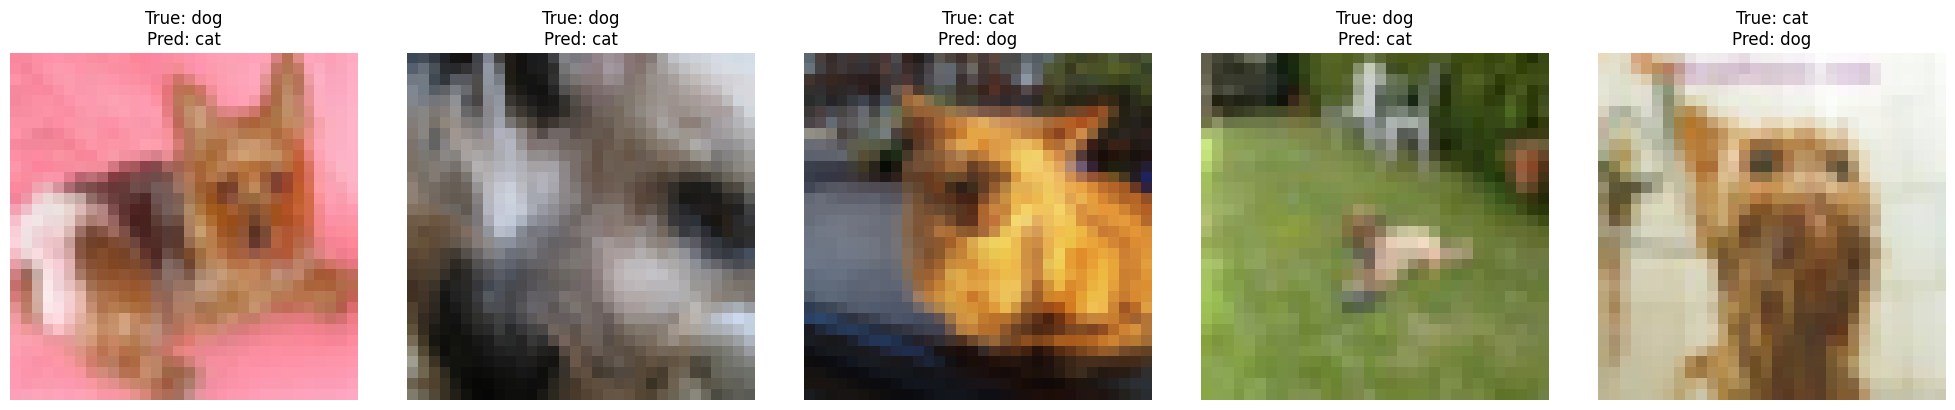


Visualizing 5 misclassifications for Car Vs Truck:


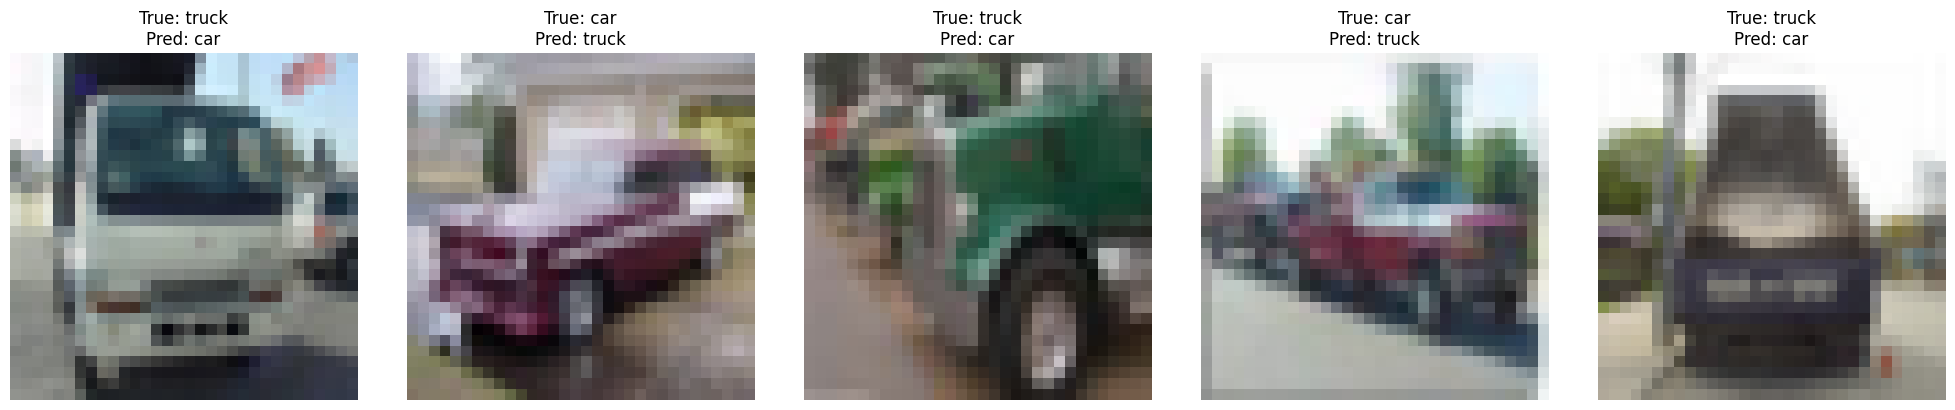


Visualizing 5 misclassifications for Ship Vs Plane:


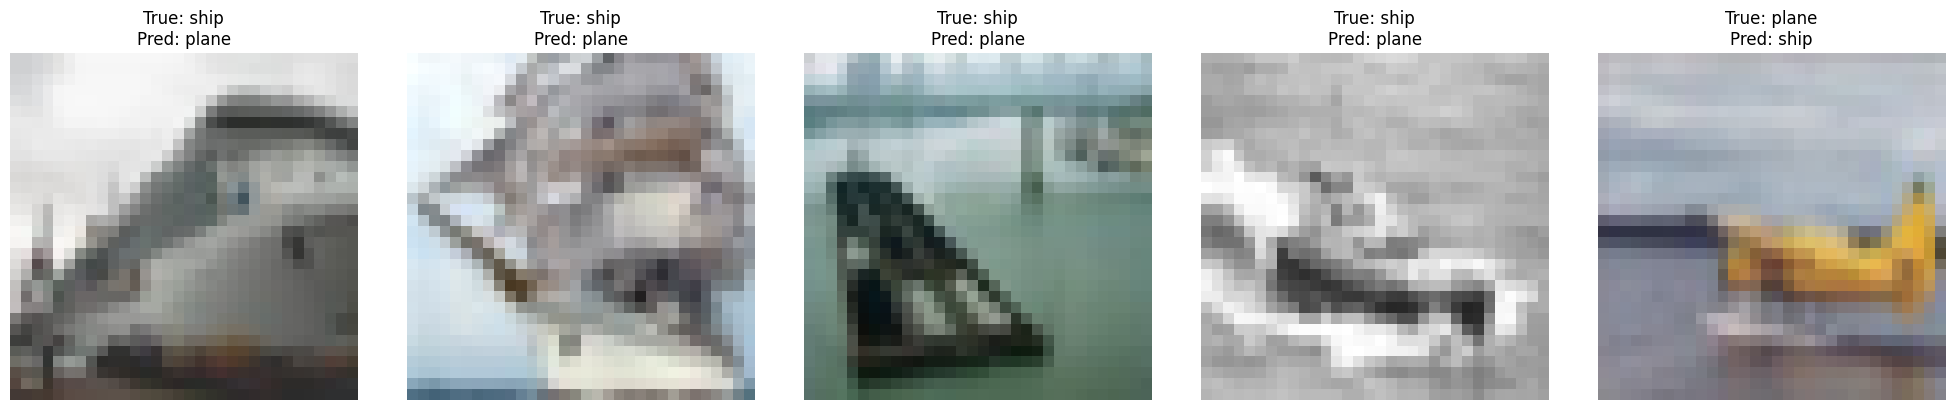

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_misclassifications(pair_name, examples, X_valid, CLASSES, num_examples=5):
    print(f"\nVisualizing {num_examples} misclassifications for {pair_name.replace('_', ' vs ').title()}:")
    fig, axes = plt.subplots(1, num_examples, figsize=(20, 4))
    if num_examples == 1:
        axes = [axes]

    selected_examples = examples[:num_examples] if len(examples) > num_examples else examples

    if not selected_examples:
        print(f"No misclassification examples to display for {pair_name}.")
        plt.close(fig)
        return

    for i, ex in enumerate(selected_examples):
        idx = ex['index']
        true_label_idx = ex['true']
        predicted_label_idx = ex['predicted']

        image = X_valid[idx] # Original image is (C, H, W)
        image = np.transpose(image, (1, 2, 0)) # Convert to (H, W, C) for matplotlib

        axes[i].imshow(image)
        axes[i].set_title(f"True: {CLASSES[true_label_idx]}\nPred: {CLASSES[predicted_label_idx]}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Visualize misclassifications for each pair
plot_misclassifications('cat_dog', misclassification_examples['cat_dog'], X_valid, CLASSES)
plot_misclassifications('car_truck', misclassification_examples['car_truck'], X_valid, CLASSES)
plot_misclassifications('ship_plane', misclassification_examples['ship_plane'], X_valid, CLASSES)
